In [161]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [163]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [164]:
import os 

In [165]:
P5hobodf = pd.read_csv('P5_current.csv')
P5hobodf = P5hobodf.dropna()
P5hobodf["Date-Time"] = pd.to_datetime(P5hobodf["Date-Time"]) 
P5hobodf.index = pd.DatetimeIndex(P5hobodf["Date-Time"]) 

In [166]:
P5filtered = hampel(P5hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [147]:
P5filtered = pd.DataFrame(P5filtered.filtered_data.to_numpy(), index=P5hobodf.index)

In [167]:
P5hobodf["FilteredTemp"] = P5filtered

In [169]:
# manual data 
P5mandf = pd.read_csv("Manual_Data_P5.csv", index_col=False) #Well_Sampling_Data_P5.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
P5mandf["Date"] = pd.to_datetime(P5mandf["Date"]) #converts the manual date-time values to pandas datetime format. 

FileNotFoundError: [Errno 2] No such file or directory: 'Manual_Data_P5.csv'

In [118]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDam2.csv")
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])

In [132]:
#reading C5 continuous data
C5hobodf = pd.read_csv("P5_creek_current.csv") 
C5hobodf["Date-Time"] = pd.to_datetime(C5hobodf["Date-Time"]) 
C5hobodf.index = pd.DatetimeIndex(C5hobodf["Date-Time"])

In [133]:
#filtering the C5 data for the outlier spikes where the hobo probe was removed from the piezometer
C5filtered = hampel(C5hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [134]:
C5filtered = pd.DataFrame(C5filtered.filtered_data.to_numpy(), index=C5hobodf.index)

In [136]:
C5hobodf["FilteredTemp"] = C5filtered

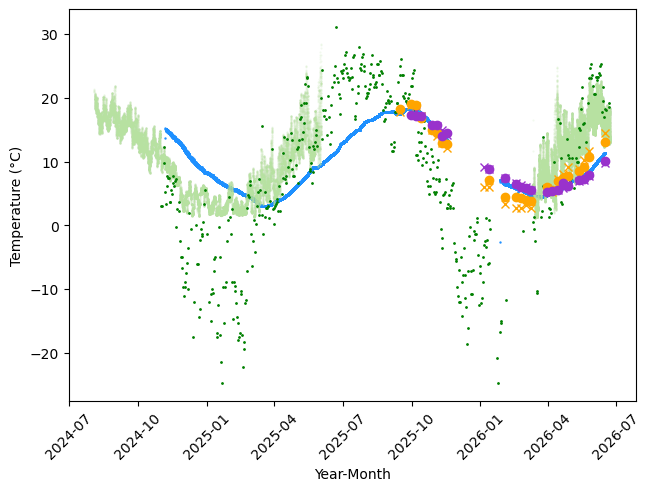

In [140]:
#creating the plot
P5mandf.columns = P5mandf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  


fig, ax = plt.subplots(layout='constrained')
#ax.plot(date1, filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.scatter(P5hobodf.index, P5hobodf.FilteredTemp, color="dodgerblue", s = 0.5, label = "P5 continuous temperature")
ax.scatter(C5hobodf.index, C5hobodf.FilteredTemp, color = "xkcd:light grey green", alpha = 0.2, s = 0.2, label = "C5 continuous temperature")
ax.plot(P5mandf.Date, P5mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime), mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"], and manual temperature at top before pumping (which you should replace with the name of the data for the legend). 
ax.plot(P5mandf.Date, P5mandf.loc[:,"Temp bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"Temp bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")
ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature")
# ax.plot(C5hobodfdate, C5filteredhobo, color = "xkcd:light grey green", label = "C5 continuous temperature data")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
# plt.ylim((0, 20))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))
# plt.ylim((6, 8))

# fig.legend(loc='outside upper right') #this line puts legend outside of graph, squishes it down, but is not awful. Run with # in front to see the graph at its default dimensions.

plt.show()

In [16]:
#P5 SPC

In [156]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
P5filteredSPC = hampel(P5hobodf["SPC"], window_size=6, n_sigma=1.5)
P5filteredSPC = pd.DataFrame(P5filteredSPC.filtered_data.to_numpy(), index=P5hobodf.index)
P5hobodf["FilteredSPC"] = P5filteredSPC

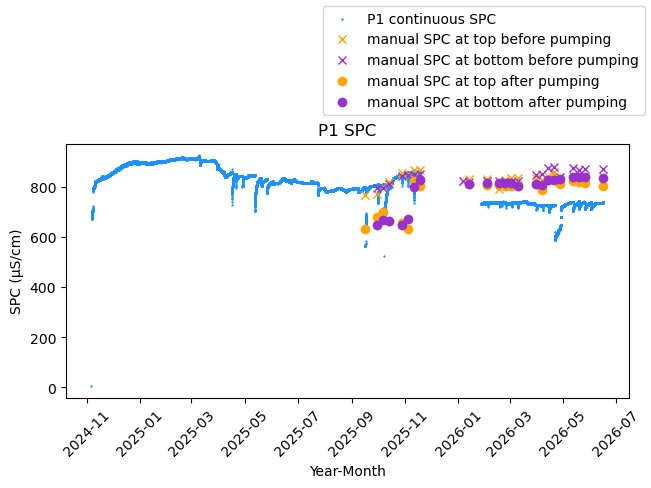

In [157]:

P5hobodate = P5hobodf["Date-Time"]
P5slicedhobodate = P5hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(P5hobodf.index, P5hobodf.FilteredSPC, color="dodgerblue", s = 0.5, label = "P5 continuous SPC")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P5 SPC")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()